# 🏥 End-to-End Exploratory Data Analysis: Healthcare Dataset

**Objective:** Perform a complete EDA on a synthetic patient health-risk dataset to understand
the data, clean it, and uncover patterns related to **heart disease risk**.

**Dataset:** `healthcare_dataset.csv` (2,025 patient records, 17 columns)

## Project Roadmap
1. [Data Understanding](#1)
2. [Statistical analysis](#2)
3. [Data Cleaning](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Multivariate Analysis](#6)
7. [Outlier Analysis (Deep Dive)](#7)
8. [Key Insights & Conclusion](#8)
---

## 0. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



%matplotlib inline


In [3]:
df = pd.read_csv('healthcare_dataset.csv')

df.head()


,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,NaN,Moderate,No,37000.0,1,No
1,P100140,88.0,Male,East,28.4,155.0,94.0,262.0,128.0,67.0,Never,NaN,Moderate,No,21000.0,8,Yes
2,P100110,37.0,Male,West,28.4,134.0,91.0,204.0,118.0,83.0,Former,NaN,Moderate,No,46000.0,2,Yes
3,P100638,75.0,Male,North,18.1,152.0,79.0,214.0,108.0,52.0,Current,NaN,Low,No,25300.0,5,Yes
4,P100702,30.0,Male,North,27.3,149.0,99.0,199.0,115.0,80.0,Former,Occasional,Low,Yes,65200.0,3,Yes


In [4]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 2025 rows x 17 columns


<a id='1'></a>
## 1. Data Understanding

Before touching the data we need to know: what columns exist, what type each is,
how much is missing, and what the target variable looks like.

### 1.1 Structure & Data Types

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 2025 non-null   str    
 1   age                        2025 non-null   float64
 2   gender                     2025 non-null   str    
 3   region                     2025 non-null   str    
 4   bmi                        1943 non-null   float64
 5   systolic_bp                2025 non-null   float64
 6   diastolic_bp               1965 non-null   float64
 7   cholesterol                1904 non-null   float64
 8   glucose                    1923 non-null   float64
 9   heart_rate                 2025 non-null   float64
 10  smoking_status             2025 non-null   str    
 11  alcohol_consumption        1211 non-null   str    
 12  exercise_level             1965 non-null   str    
 13  family_history             2025 non-null   str    
 14  ann

### 1.2 Column Dictionary

| Column | Description |
|---|---|
| patient_id | Unique patient identifier |
| age | Age in years |
| gender | Male / Female (raw data has inconsistent labels) |
| region | Geographic region |
| bmi | Body Mass Index |
| systolic_bp / diastolic_bp | Blood pressure readings (mmHg) |
| cholesterol | Total cholesterol (mg/dL) |
| glucose | Fasting glucose (mg/dL) |
| heart_rate | Resting heart rate (bpm) |
| smoking_status | Never / Former / Current |
| alcohol_consumption | None / Occasional / Regular |
| exercise_level | Low / Moderate / High |
| family_history | Family history of heart disease (Yes/No) |
| annual_income | Annual income (may contain invalid negatives) |
| hospital_visits_last_year | Count of hospital visits |
| heart_disease | **Target** — Yes/No |


### 1.3 Descriptive Statistics

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,2025.0,53.779423,21.048602,18.0,35.0,54.0,72.00,108.017232
bmi,1943.0,26.307874,4.760546,14.0,23.0,26.1,29.35,44.200000
systolic_bp,2025.0,144.104620,14.112953,103.0,135.0,144.0,152.00,258.041051
diastolic_bp,1965.0,86.173028,7.255701,62.0,81.0,86.0,91.00,110.000000
cholesterol,1904.0,216.598407,33.587026,148.0,198.0,214.0,232.00,487.924410
glucose,1923.0,118.570463,14.405478,62.0,109.0,118.0,128.00,168.000000
heart_rate,2025.0,71.190617,8.990235,41.0,65.0,71.0,77.00,99.000000
annual_income,1862.0,41985.392052,22887.161266,-57600.0,26600.0,37300.0,51000.00,191700.000000
hospital_visits_last_year,2025.0,3.318025,1.877839,0.0,2.0,3.0,5.00,11.000000


- annual income has outliers

In [7]:
df["gender"].value_counts()

gender
Female    1008
Male       977
F            8
male         8
FEMALE       7
MALE         7
female       7
M            3
Name: count, dtype: int64

In [8]:
df.describe(include='object').T


C:\Users\LakshmanAIMLHYD\AppData\Local\Temp\ipykernel_14564\607101935.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
patient_id,2025,2000,P101926,2
gender,2025,8,Female,1008
region,2025,4,North,594
smoking_status,2025,3,Never,1120
alcohol_consumption,1211,2,Occasional,865
exercise_level,1965,3,Moderate,906
family_history,2025,2,No,1371
heart_disease,2025,2,Yes,1495


- Data Preprocessing (Data cleaning)

### 1.4 Missing Values Overview

In [9]:
df.isnull()

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,alcohol_consumption,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2021,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
2022,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2023,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
region                         0
bmi                           82
systolic_bp                    0
diastolic_bp                  60
cholesterol                  121
glucose                      102
heart_rate                     0
smoking_status                 0
alcohol_consumption          814
exercise_level                60
family_history                 0
annual_income                163
hospital_visits_last_year      0
heart_disease                  0
dtype: int64

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
alcohol_consumption,814,40.20
annual_income,163,8.05
cholesterol,121,5.98
glucose,102,5.04
bmi,82,4.05
diastolic_bp,60,2.96
exercise_level,60,2.96


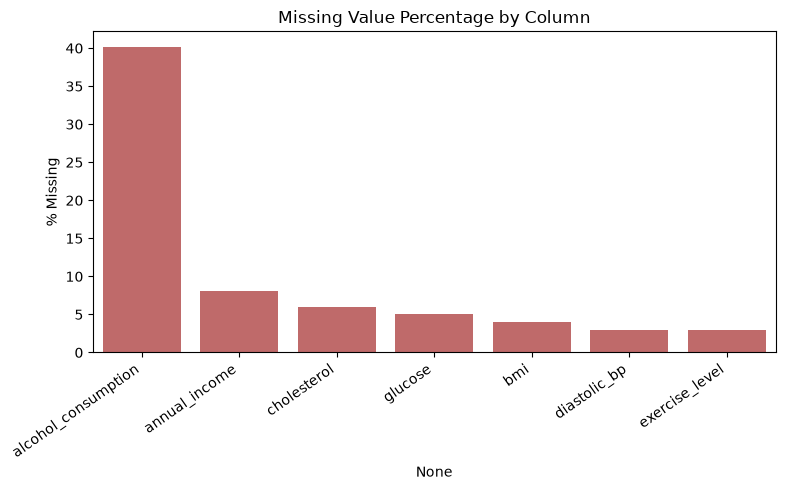

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'], color='indianred')
plt.xticks(rotation=35, ha='right')
plt.ylabel('% Missing')
plt.title('Missing Value Percentage by Column')
plt.tight_layout()
plt.show()


### 1.5 Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(24)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(2001, 17)

In [16]:
df.gender.value_counts()

gender
Female    995
Male      966
F           8
male        8
FEMALE      7
MALE        7
female      7
M           3
Name: count, dtype: int64

### 2.1 Fix Inconsistent Categorical Labels

In [17]:
print("Before:", df['gender'].unique())

gender_map = {
    'M': 'Male', 'male': 'Male', 'MALE': 'Male',
    'F': 'Female', 'female': 'Female', 'FEMALE': 'Female'
}
df['gender'] = df['gender'].replace(gender_map)

print("After:", df['gender'].unique())


Before: <StringArray>
['Female', 'Male', 'FEMALE', 'MALE', 'female', 'M', 'F', 'male']
Length: 8, dtype: str
After: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [18]:
df.gender.value_counts()

gender
Female    1017
Male       984
Name: count, dtype: int64

In [19]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
region                         0
bmi                           80
systolic_bp                    0
diastolic_bp                  60
cholesterol                  119
glucose                      100
heart_rate                     0
smoking_status                 0
alcohol_consumption          797
exercise_level                60
family_history                 0
annual_income                160
hospital_visits_last_year      0
heart_disease                  0
dtype: int64

### 2.5 Handle Missing Values

Strategy:
- **Numeric columns** (`bmi`, `cholesterol`, `glucose`, `diastolic_bp`, `annual_income`): impute with the **median** (robust to skew/outliers).
- **Categorical columns** (`exercise_level`, `alcohol_consumption`): impute with the **mode** (most frequent category).


In [20]:
df.drop(columns=["alcohol_consumption"],inplace=True)

In [21]:
df.columns

Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'glucose', 'heart_rate',
       'smoking_status', 'exercise_level', 'family_history', 'annual_income',
       'hospital_visits_last_year', 'heart_disease'],
      dtype='str')

In [22]:
df.bmi=df.bmi.fillna(df.bmi.mean())

In [23]:
df.isnull().sum()

patient_id                     0
age                            0
gender                         0
region                         0
bmi                            0
systolic_bp                    0
diastolic_bp                  60
cholesterol                  119
glucose                      100
heart_rate                     0
smoking_status                 0
exercise_level                60
family_history                 0
annual_income                160
hospital_visits_last_year      0
heart_disease                  0
dtype: int64

In [24]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,Moderate,No,37000.0,1,No


In [25]:
df.diastolic_bp=df.diastolic_bp.fillna(df.diastolic_bp.mean())

In [26]:
df.cholesterol=df.cholesterol.fillna(df.cholesterol.mean())

In [27]:
df["glucose"]=df["glucose"].fillna(df["glucose"].mean())

In [28]:
df["exercise_level"]=df["exercise_level"].fillna(df["exercise_level"].mode()[0])

In [29]:
df["annual_income"]=df["annual_income"].fillna(df["annual_income"].median())

In [30]:
df.isnull().sum()

patient_id                   0
age                          0
gender                       0
region                       0
bmi                          0
systolic_bp                  0
diastolic_bp                 0
cholesterol                  0
glucose                      0
heart_rate                   0
smoking_status               0
exercise_level               0
family_history               0
annual_income                0
hospital_visits_last_year    0
heart_disease                0
dtype: int64

In [31]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,P101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,Moderate,No,37000.0,1,No


In [32]:
df.dtypes

patient_id                       str
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

In [33]:
df["patient_id"]=df["patient_id"].str.replace("P",' ')

In [34]:
df["patient_id"]=df["patient_id"].astype("int64")

In [35]:
df.dtypes

patient_id                     int64
age                          float64
gender                           str
region                           str
bmi                          float64
systolic_bp                  float64
diastolic_bp                 float64
cholesterol                  float64
glucose                      float64
heart_rate                   float64
smoking_status                   str
exercise_level                   str
family_history                   str
annual_income                float64
hospital_visits_last_year      int64
heart_disease                    str
dtype: object

- EDA:

- Univariate Analysis:

analying of one variable or one column at a time is called univariate analysis


- Bi variate analysis:

analying of two  variable or two  column at a time is called bivariate analysis


- Multivariate Analysis:
 
 analying of morethan two   variable or two  column at a time is called multi variate analysis

In [36]:
df.columns

Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'systolic_bp',
       'diastolic_bp', 'cholesterol', 'glucose', 'heart_rate',
       'smoking_status', 'exercise_level', 'family_history', 'annual_income',
       'hospital_visits_last_year', 'heart_disease'],
      dtype='str')

In [37]:
numerical_features=df.select_dtypes(include="number").columns.tolist()

categorical_features=df.select_dtypes(include=["object","category"]).columns.tolist()

C:\Users\LakshmanAIMLHYD\AppData\Local\Temp\ipykernel_14564\3010715408.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=df.select_dtypes(include=["object","category"]).columns.tolist()


In [38]:
numerical_features

['patient_id',
 'age',
 'bmi',
 'systolic_bp',
 'diastolic_bp',
 'cholesterol',
 'glucose',
 'heart_rate',
 'annual_income',
 'hospital_visits_last_year']

In [39]:
categorical_features

['gender',
 'region',
 'smoking_status',
 'exercise_level',
 'family_history',
 'heart_disease']

- univariate_analysis


 patient_id
************
count      2001.000000
mean     100999.115942
std         577.605747
min      100000.000000
25%      100499.000000
50%      100999.000000
75%      101499.000000
max      101999.000000
Name: patient_id, dtype: float64


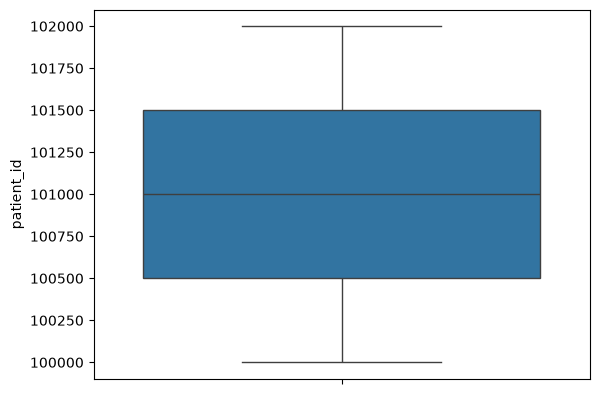


 age
************
count    2001.000000
mean       53.731468
std        21.066002
min        18.000000
25%        35.000000
50%        54.000000
75%        72.000000
max       108.017232
Name: age, dtype: float64


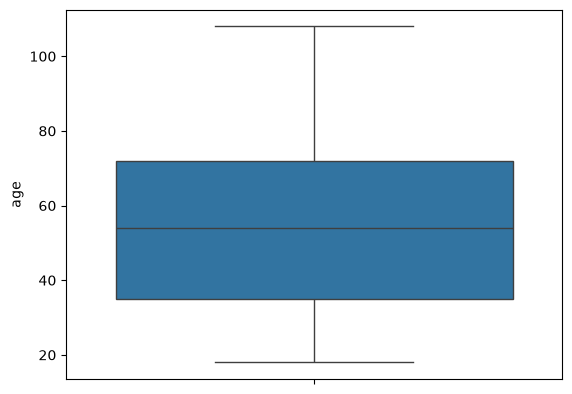


 bmi
************
count    2001.000000
mean       26.309006
std         4.655843
min        14.000000
25%        23.200000
50%        26.309006
75%        29.200000
max        44.200000
Name: bmi, dtype: float64


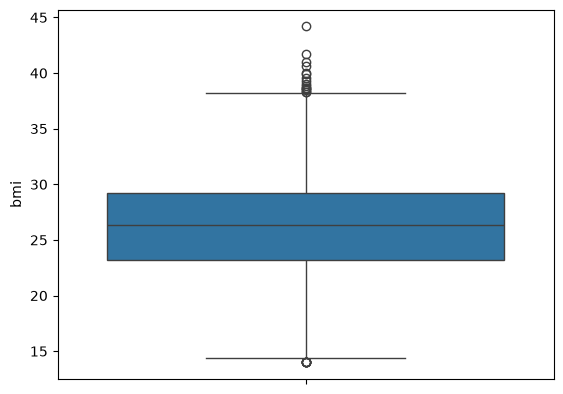


 systolic_bp
************
count    2001.000000
mean      144.124366
std        14.129779
min       103.000000
25%       135.000000
50%       144.000000
75%       152.000000
max       258.041051
Name: systolic_bp, dtype: float64


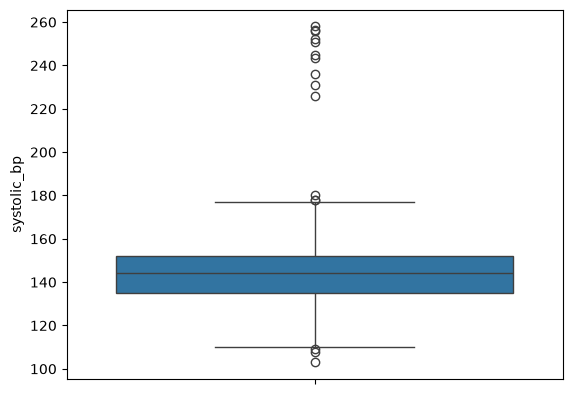


 diastolic_bp
************
count    2001.000000
mean       86.178259
std         7.152074
min        62.000000
25%        81.000000
50%        86.000000
75%        91.000000
max       110.000000
Name: diastolic_bp, dtype: float64


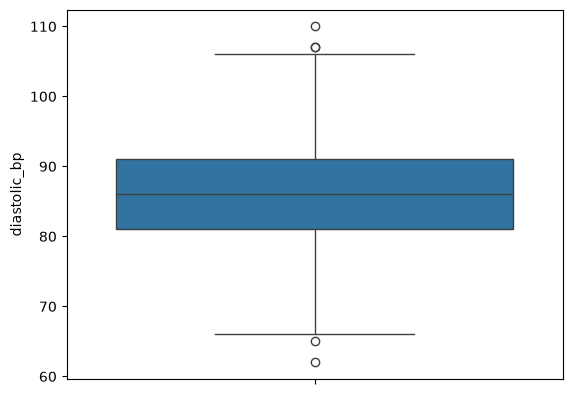


 cholesterol
************
count    2001.000000
mean      216.317008
std        31.805239
min       148.000000
25%       199.000000
50%       216.317008
75%       231.000000
max       487.924410
Name: cholesterol, dtype: float64


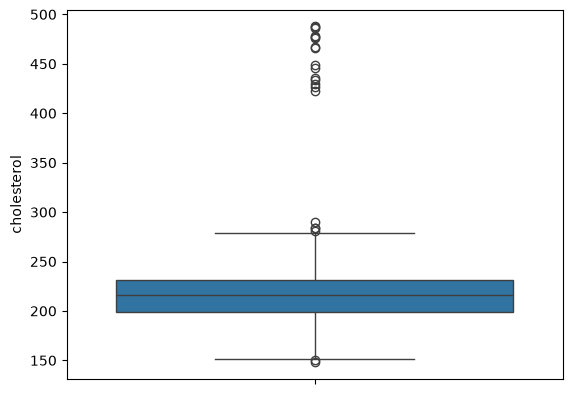


 glucose
************
count    2001.000000
mean      118.578643
std        14.049119
min        62.000000
25%       109.000000
50%       118.578643
75%       128.000000
max       168.000000
Name: glucose, dtype: float64


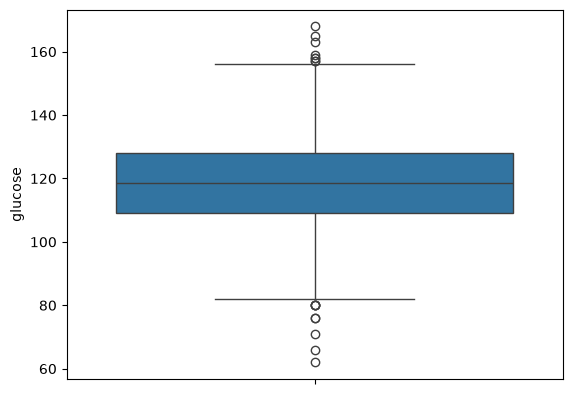


 heart_rate
************
count    2001.000000
mean       71.175412
std         9.005316
min        41.000000
25%        65.000000
50%        71.000000
75%        77.000000
max        99.000000
Name: heart_rate, dtype: float64


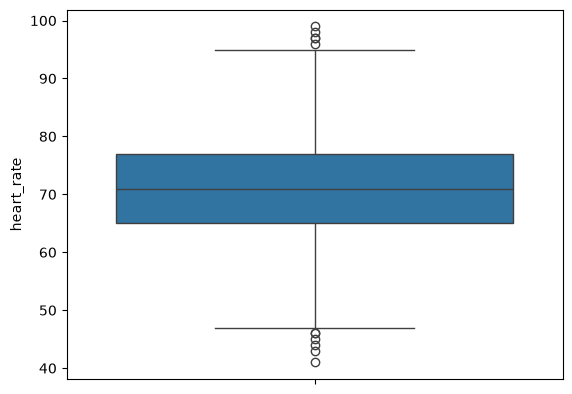


 annual_income
************
count      2001.000000
mean      41575.012494
std       21947.658994
min      -57600.000000
25%       27400.000000
50%       37300.000000
75%       49300.000000
max      191700.000000
Name: annual_income, dtype: float64


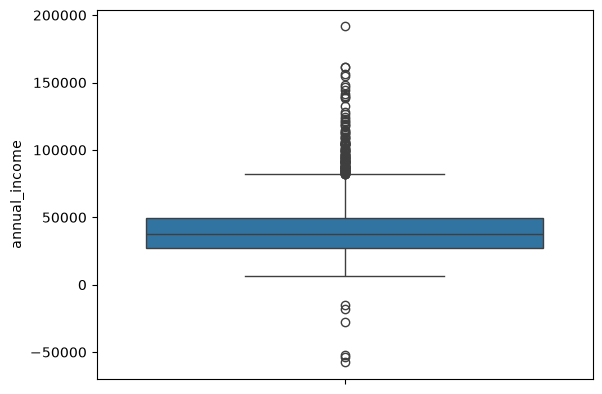


 hospital_visits_last_year
************
count    2001.000000
mean        3.315342
std         1.879364
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        11.000000
Name: hospital_visits_last_year, dtype: float64


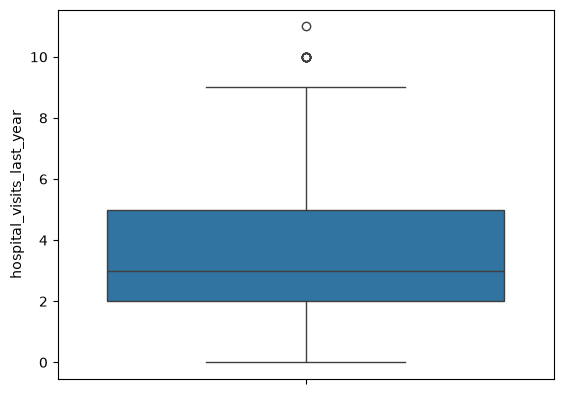

In [40]:
for col in numerical_features:
    print("\n",col)
    print("************")
    print(df[col].describe())
    sns.boxplot(df[col])
    plt.show()

In [41]:
import math

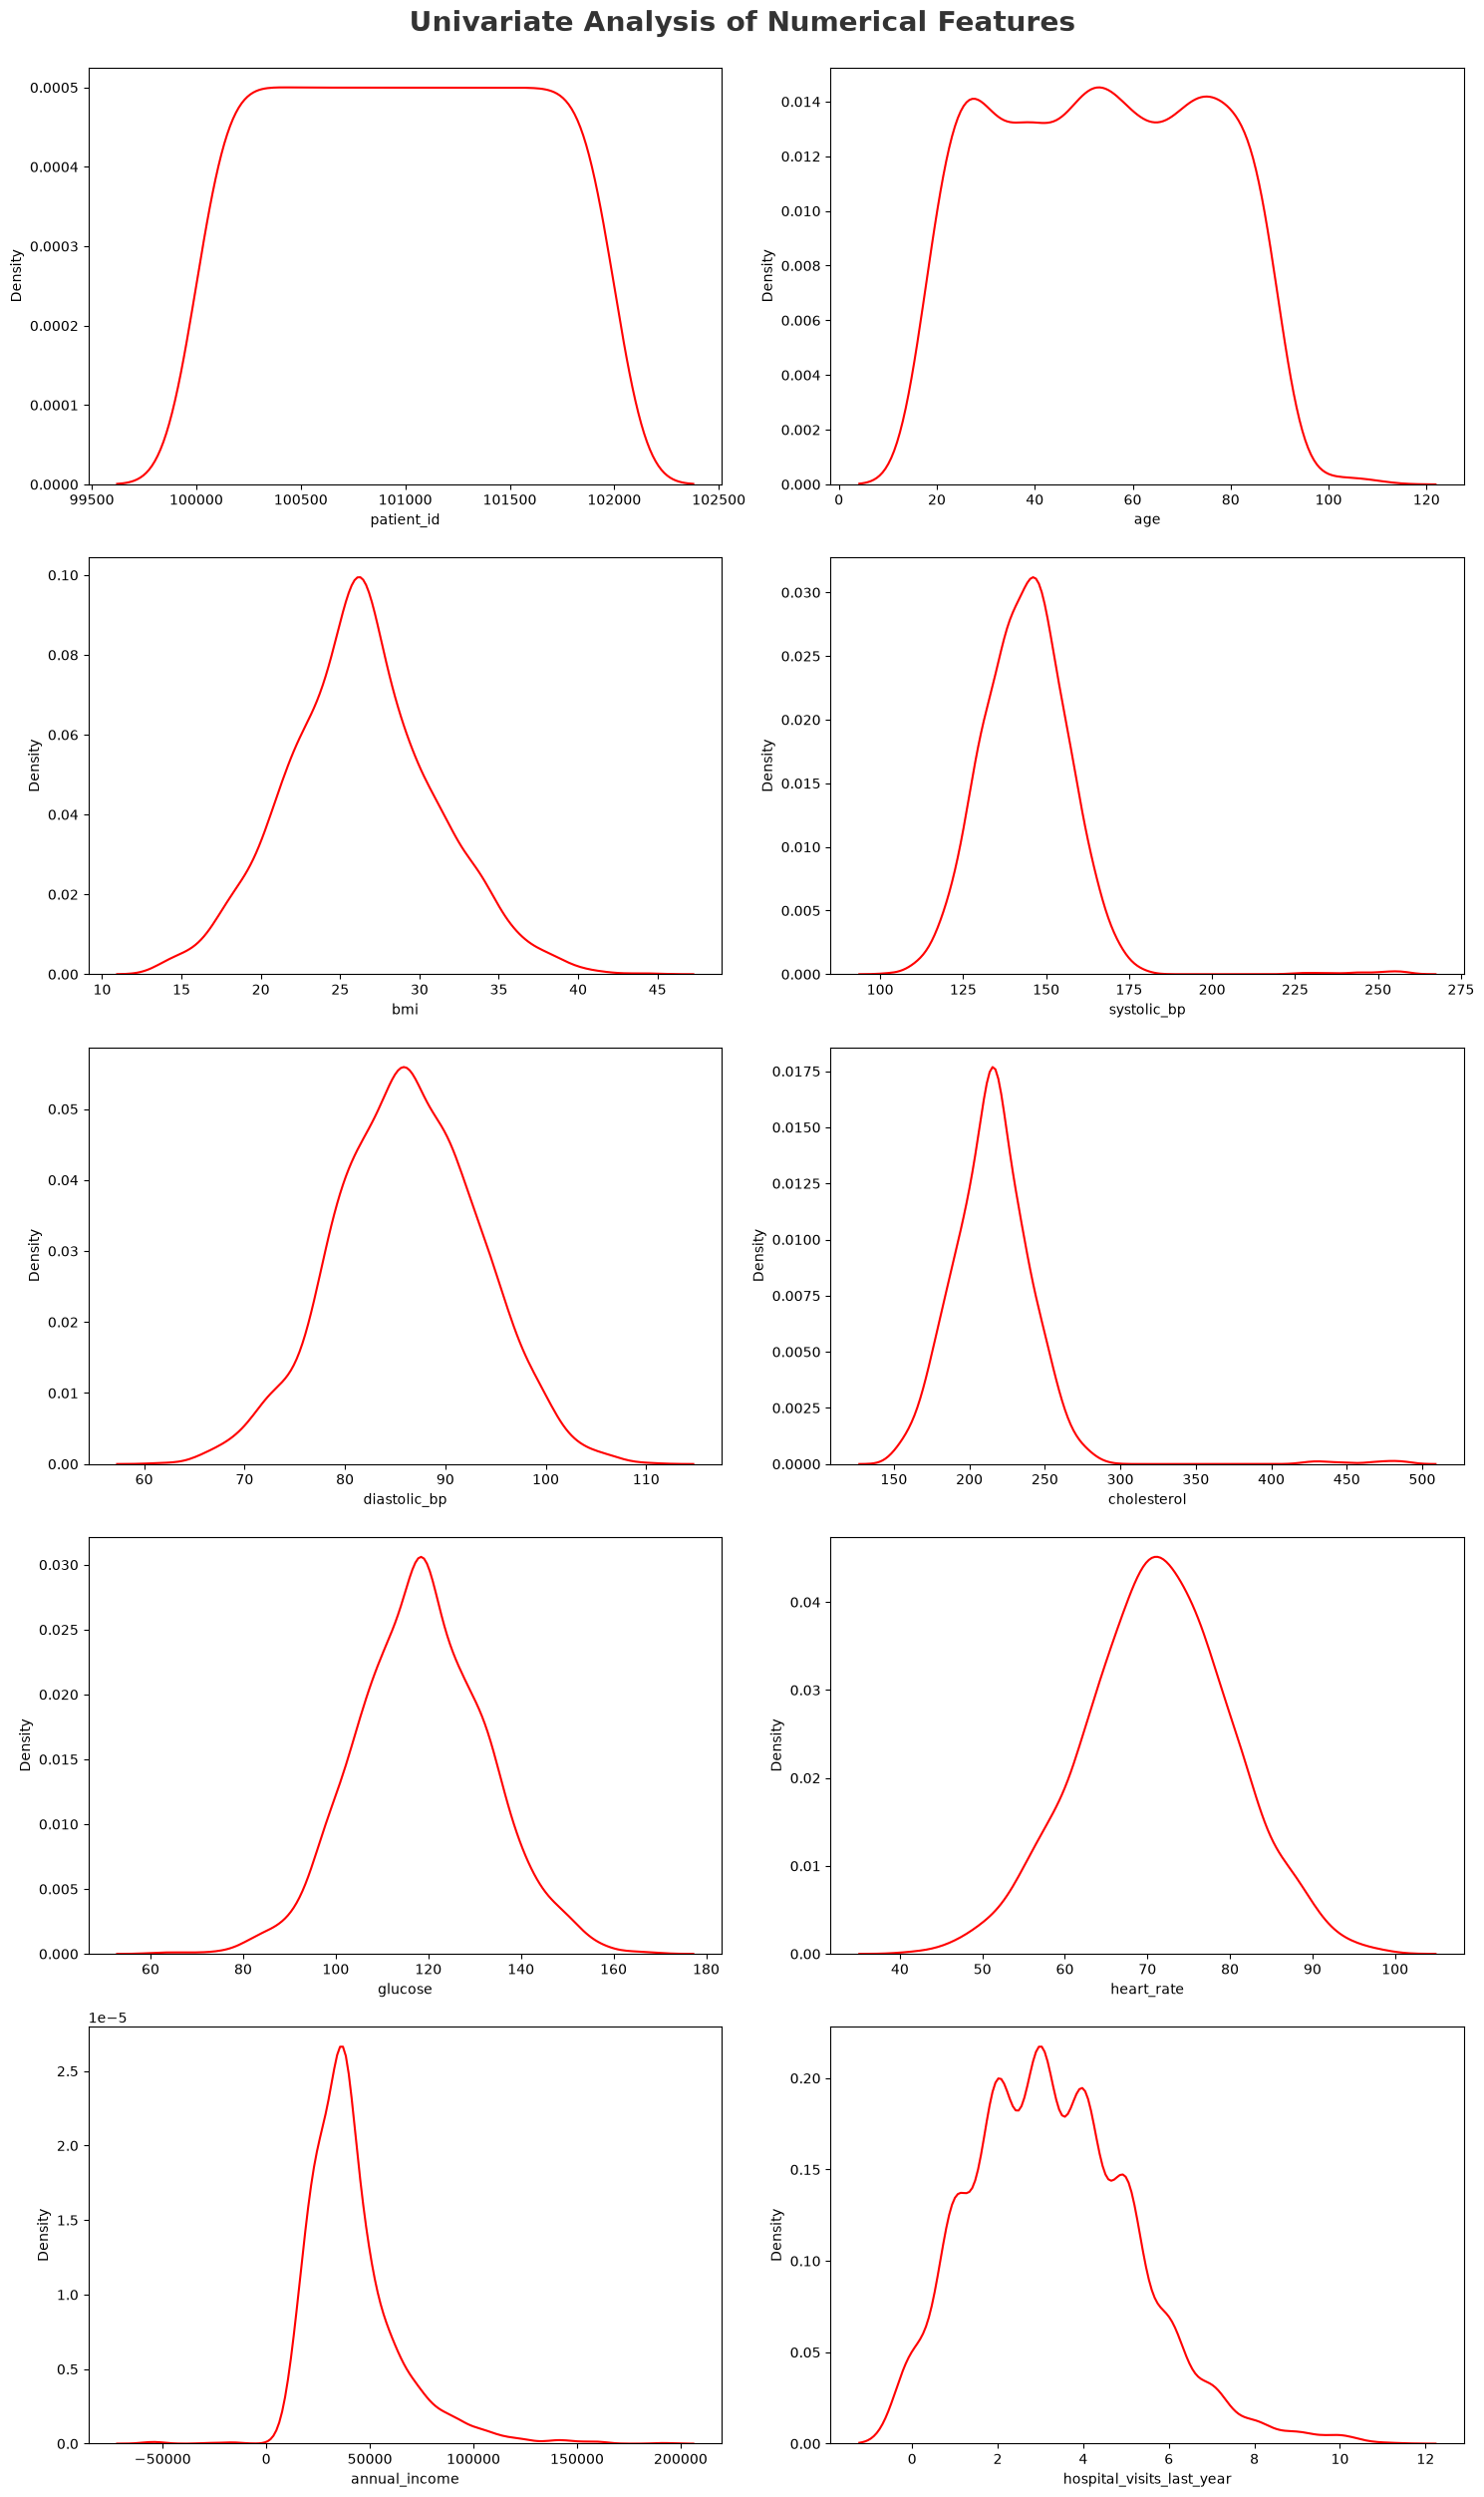

In [42]:
# Calculate the number of rows and columns based on the number of features
n_features = len(numerical_features)
n_cols = 2# You can adjust this as needed (e.g., 2 columns for 6 features)
n_rows = int(np.ceil(n_features / n_cols))  # Calculate rows to fit all features

# Create the plot
plt.figure(figsize=(15, 5 * n_rows))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Loop to create subplots for each numerical feature
for i in range(n_features):
    plt.subplot(n_rows, n_cols, i+1)  # Dynamically set subplot grid
    sns.kdeplot(x=df[numerical_features[i]], color='red')
    plt.xlabel(numerical_features[i])

plt.tight_layout()
plt.show()

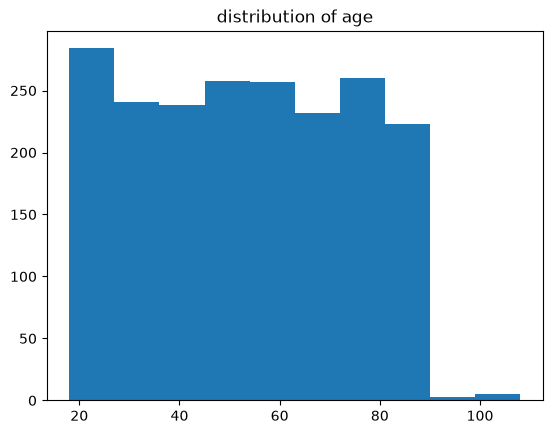

In [52]:
plt.hist(df['age'], bins=10)
plt.title("distribution of age")
plt.show()

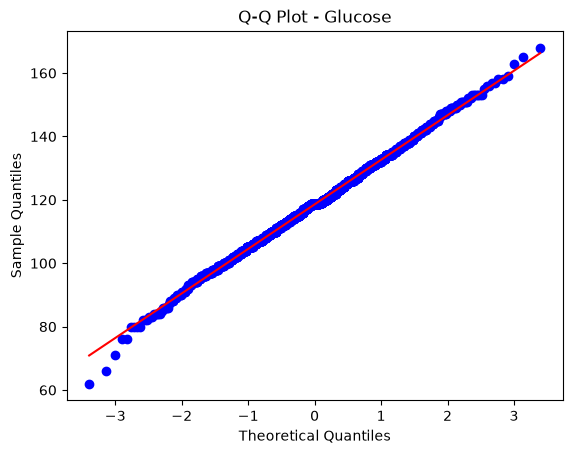

In [53]:
import scipy.stats as stats

stats.probplot(df['glucose'], dist="norm", plot=plt)

plt.title('Q-Q Plot - Glucose')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

-  univariate analysis of categorical features 


 gender
*************
count       2001
unique         2
top       Female
freq        1017
Name: gender, dtype: object


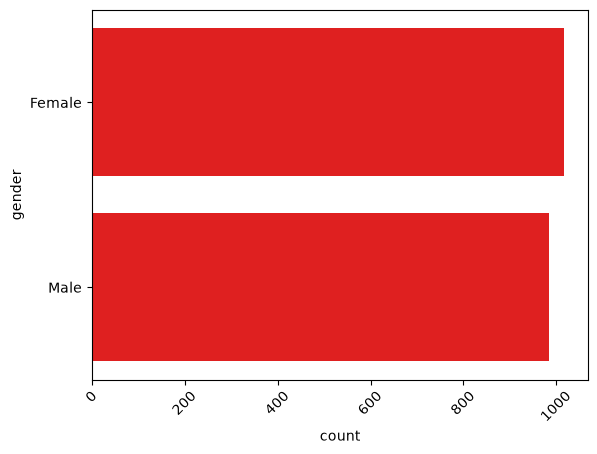


 region
*************
count      2001
unique        4
top       North
freq        587
Name: region, dtype: object


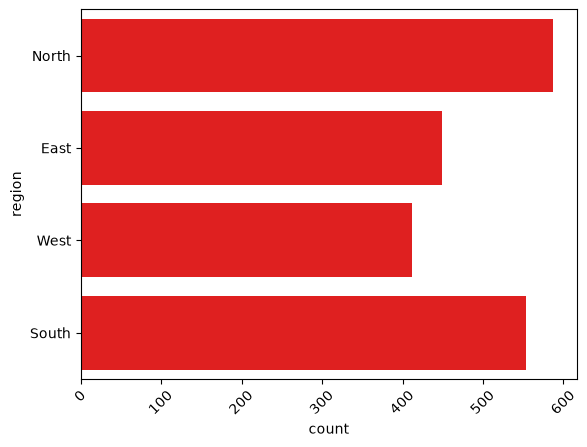


 smoking_status
*************
count      2001
unique        3
top       Never
freq       1105
Name: smoking_status, dtype: object


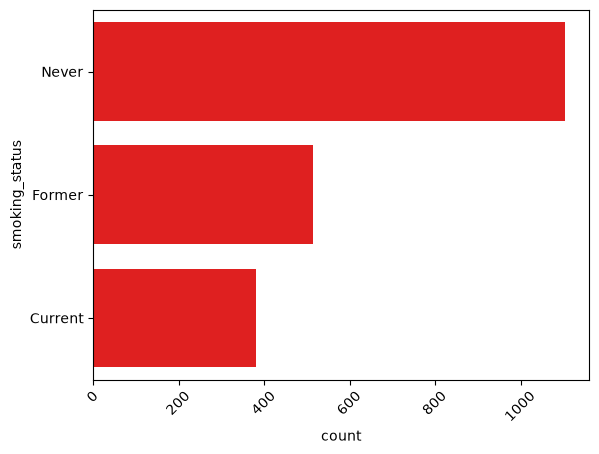


 exercise_level
*************
count         2001
unique           3
top       Moderate
freq           956
Name: exercise_level, dtype: object


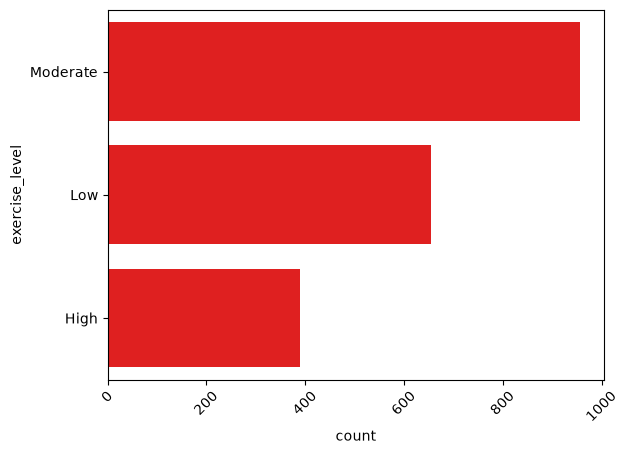


 family_history
*************
count     2001
unique       2
top         No
freq      1353
Name: family_history, dtype: object


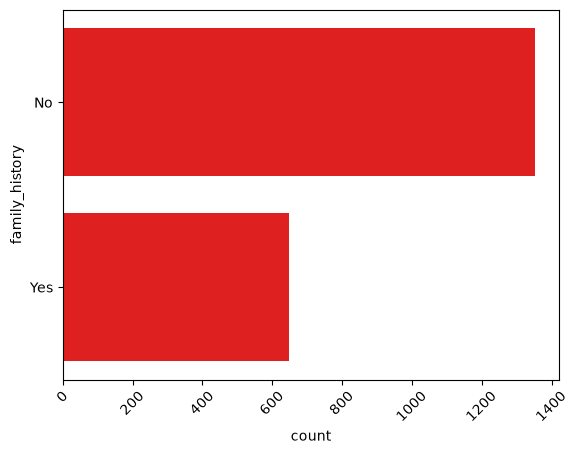


 heart_disease
*************
count     2001
unique       2
top        Yes
freq      1477
Name: heart_disease, dtype: object


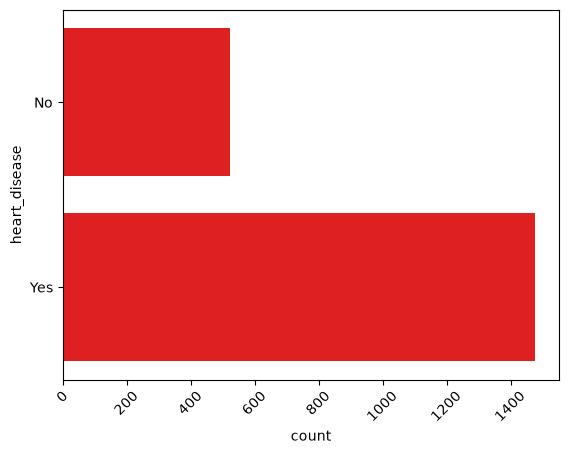

In [43]:
for col in categorical_features:
    print("\n",col)
    print("*************")
    print(df[col].describe())
    sns.countplot(df[col],color="red")
    plt.xticks(rotation=45)
    plt.show()

In [44]:
categorical_features

['gender',
 'region',
 'smoking_status',
 'exercise_level',
 'family_history',
 'heart_disease']

In [45]:
df.gender.value_counts(normalize=True)

gender
Female    0.508246
Male      0.491754
Name: proportion, dtype: float64

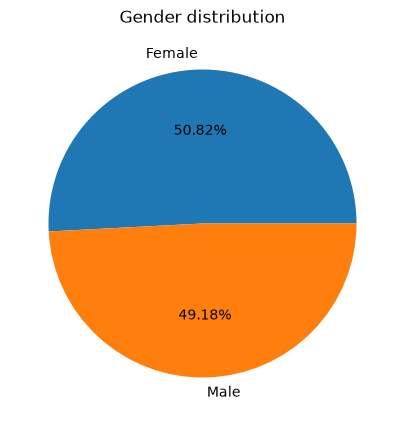

In [46]:
plt.figure(figsize=(8,5))

plt.pie(df.gender.value_counts().values ,labels=df.gender.value_counts().index,autopct="%1.2f%%" )
plt.title("Gender distribution")
plt.show()

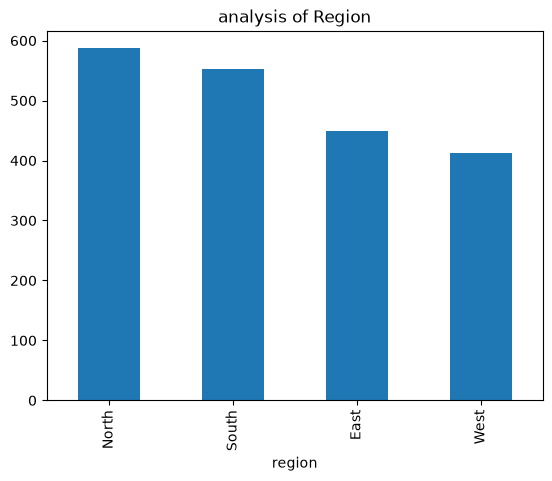

In [49]:
df['region'].value_counts().plot(kind="bar")

plt.title("analysis of Region")
plt.show()

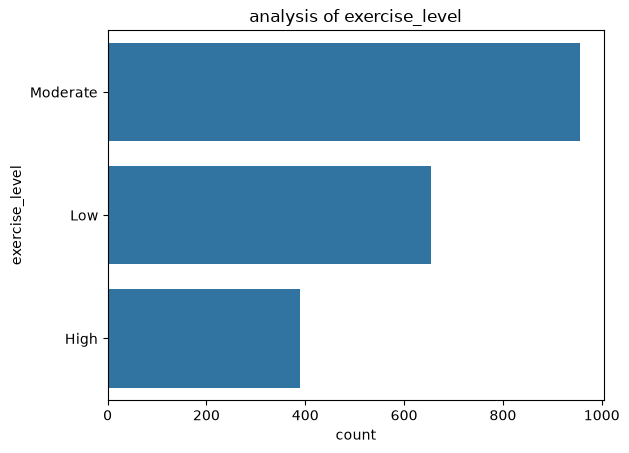

In [51]:
sns.countplot(df["exercise_level"])
plt.title("analysis of exercise_level")
plt.show()

- Bi variate analysis

In [55]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,Moderate,No,37000.0,1,No


- scatter plot (num- num)

<Axes: xlabel='cholesterol', ylabel='bmi'>

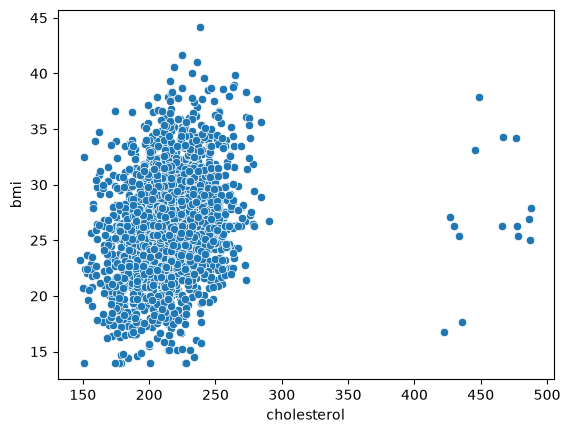

In [57]:
sns.scatterplot(y=df['bmi'], x=df['cholesterol'])

<Axes: xlabel='cholesterol', ylabel='bmi'>

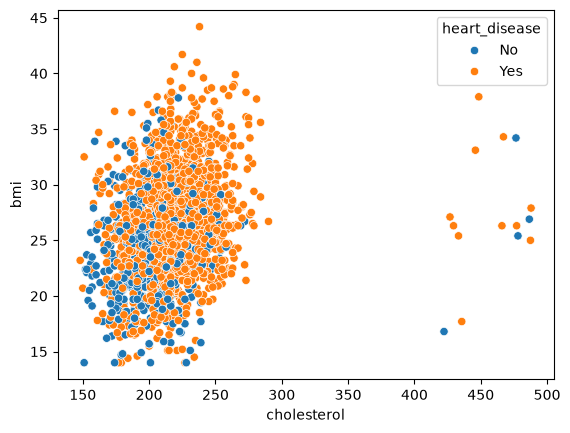

In [58]:
sns.scatterplot(y=df['bmi'], x=df['cholesterol'],hue=df["heart_disease"])

<Axes: xlabel='exercise_level', ylabel='cholesterol'>

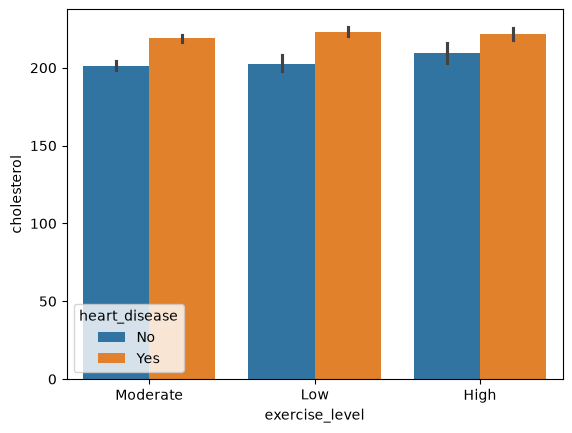

In [61]:
sns.barplot(y=df['cholesterol'], x=df['exercise_level'],hue=df["heart_disease"])

In [63]:
df.head(1)

,patient_id,age,gender,region,bmi,systolic_bp,diastolic_bp,cholesterol,glucose,heart_rate,smoking_status,exercise_level,family_history,annual_income,hospital_visits_last_year,heart_disease
0,101028,58.0,Female,North,16.4,133.0,83.0,172.0,106.0,78.0,Never,Moderate,No,37000.0,1,No


- Box plot (NUM-CAT)

<Axes: xlabel='gender', ylabel='glucose'>

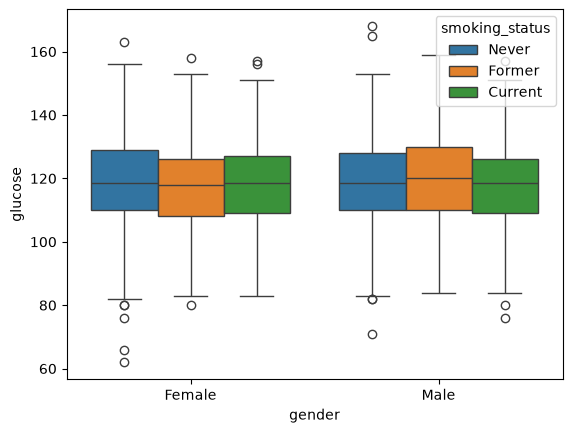

In [65]:
sns.boxplot(x=df['gender'], y=df['glucose'],hue=df["smoking_status"])

<Axes: xlabel='systolic_bp', ylabel='cholesterol'>

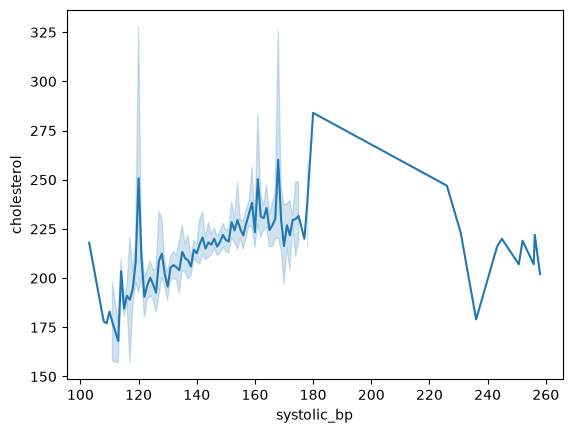

In [70]:
sns.lineplot(x=df["systolic_bp"],y=df["cholesterol"])

### 5.3 Age vs Key Vitals (Scatter with Regression)

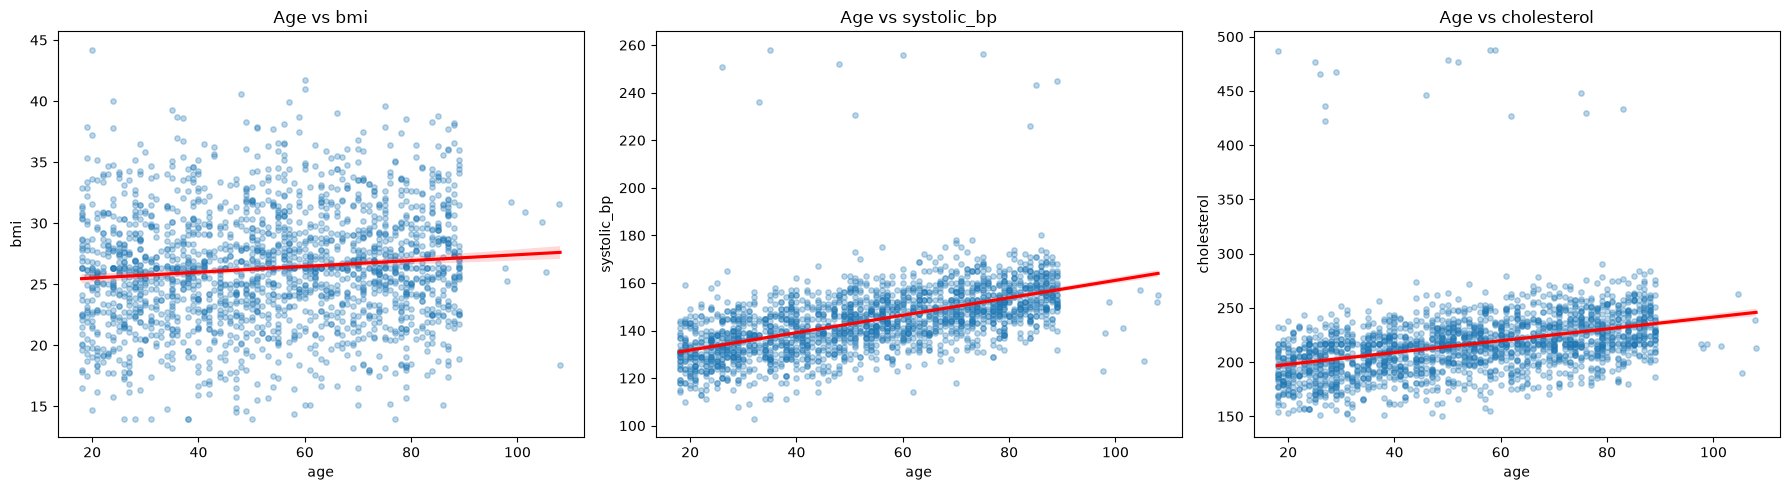

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['bmi', 'systolic_bp', 'cholesterol']):
    sns.regplot(x='age', y=col, data=df, ax=ax, scatter_kws={'alpha':0.3, 's':15},
                line_kws={'color':'red'})
    ax.set_title(f'Age vs {col}')
plt.tight_layout()
plt.show()


3. Multivariate analysis

### 5.4 Correlation Between Numeric Variables

In [75]:
df.drop(columns=["patient_id"],inplace=True)

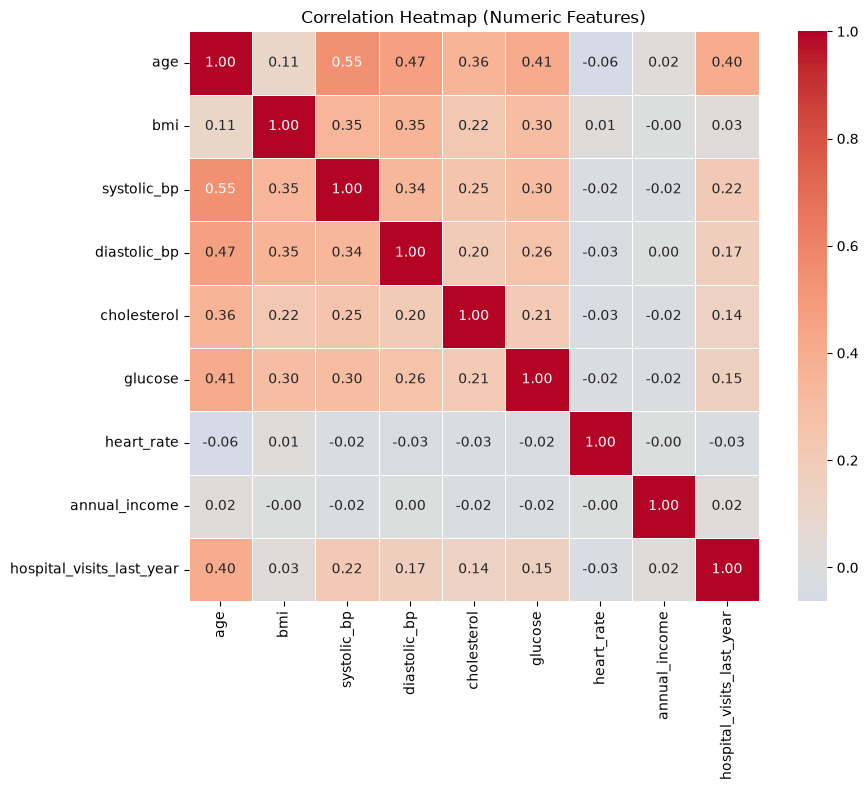

In [76]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


### 5.5 Cross-tabulations

In [77]:
pd.crosstab(df['smoking_status'], df['heart_disease'], margins=True)


heart_disease,No,Yes,All
smoking_status,,,
Current,61,320,381
Former,158,357,515
Never,305,800,1105
All,524,1477,2001


In [78]:
pd.crosstab(df['exercise_level'], df['heart_disease'], normalize='index').round(3) * 100


heart_disease,No,Yes
exercise_level,,
High,37.9,62.1
Low,22.0,78.0
Moderate,24.3,75.7


### 6.1 Pairplot Colored by Target

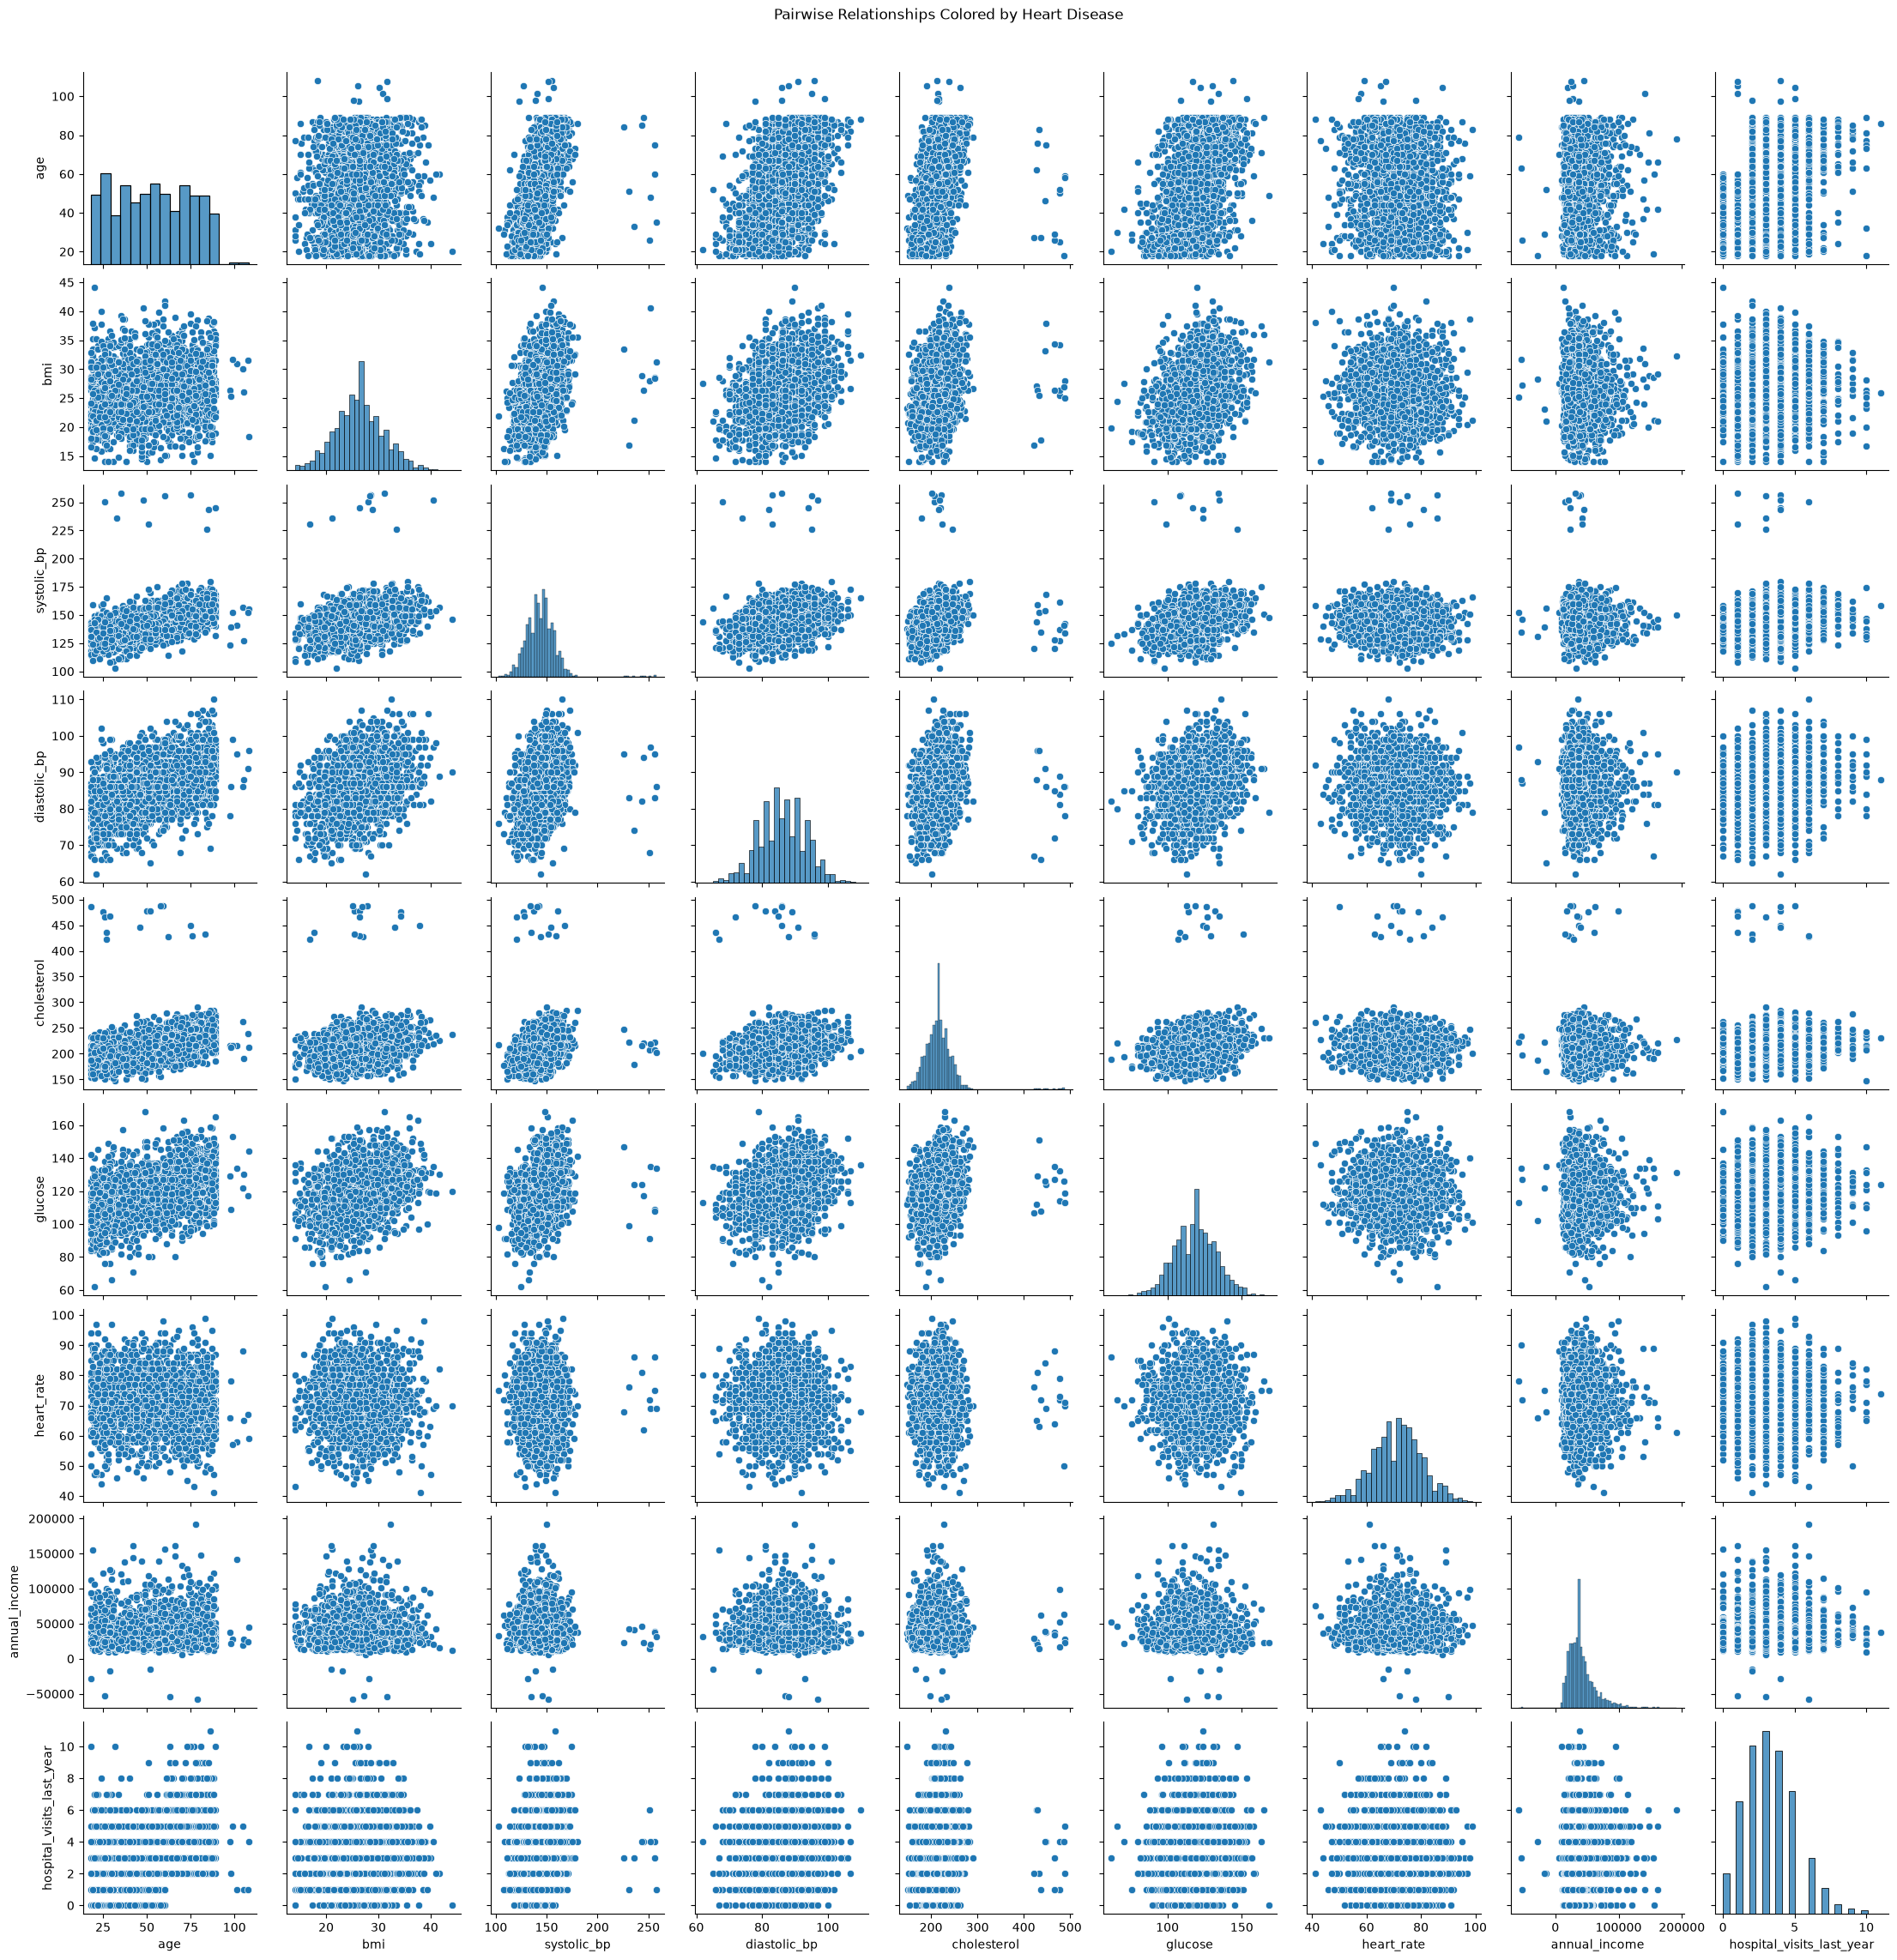

In [79]:

sns.pairplot(df)
plt.suptitle('Pairwise Relationships Colored by Heart Disease', y=1.02)
plt.show()


### 6.3 Heart Disease Rate by Smoking Status AND Exercise Level (Heatmap)

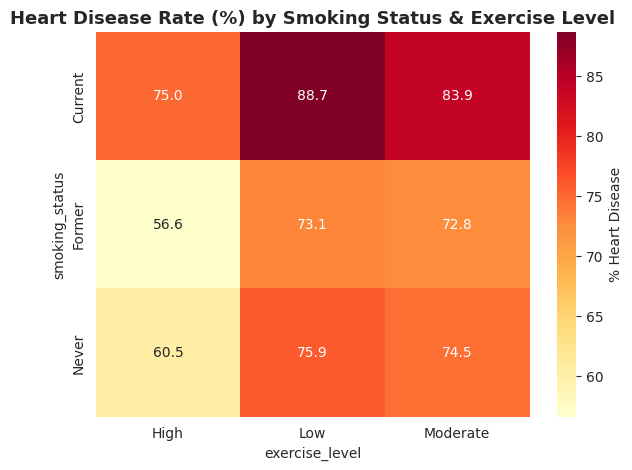

In [33]:
pivot = df.pivot_table(index='smoking_status', columns='exercise_level',
                        values='heart_disease_flag', aggfunc='mean') * 100
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% Heart Disease'})
plt.title('Heart Disease Rate (%) by Smoking Status & Exercise Level')
plt.show()


<a id='9'></a>
## 9. Key Insights & Conclusion

**Data Quality**
- Raw dataset had inconsistent gender labels, ~5-8% missingness in several columns,
  25 duplicate rows, and a handful of invalid/negative income values — all resolved in Section 2.

**Univariate Findings**
- `annual_income` and `hospital_visits_last_year` are right-skewed (long tail of high earners / frequent visitors).
- Most vitals (`bmi`, `cholesterol`, `systolic_bp`) are roughly normal after outlier capping.
- The target class (`heart_disease`) is moderately imbalanced — worth noting for any future modeling.

**Bivariate Findings**
- `age`, `bmi`, `systolic_bp`, `cholesterol`, and `glucose` are all **positively associated** with heart disease risk.
- Current smokers and patients with a family history show a visibly higher heart-disease rate.
- High exercise levels are associated with lower heart-disease prevalence.

**Multivariate Findings**
- The combination of *current smoker + low exercise* shows the highest heart-disease rate in the heatmap.
- Older patients with high BMI and high cholesterol cluster heavily in the "Yes" heart-disease group.


